# Sparse Pruning Regression Demo
Use sparse-pruning trees from `imodels` on a regression dataset.

In [1]:
import numpy as np

from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

from imodels import SPTreeRegressor, SPTreeRegressorCV
from sklearn import tree
import matplotlib.pyplot as plt

In [2]:
X, y = load_diabetes(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

In [23]:
sp_tree = SPTreeRegressorCV(
    estimator_=DecisionTreeRegressor(max_leaf_nodes=20, random_state=42),
    sp_alpha_list=[4000],
    reg_param_list=[0, 10, 50, 100],
    cv=3,
    random_state=42,
)
sp_tree.fit(X_train, y_train)

sp_tree_mse = mean_squared_error(y_test, sp_tree.predict(X_test))
sp_tree_mse

3739.5456103831384

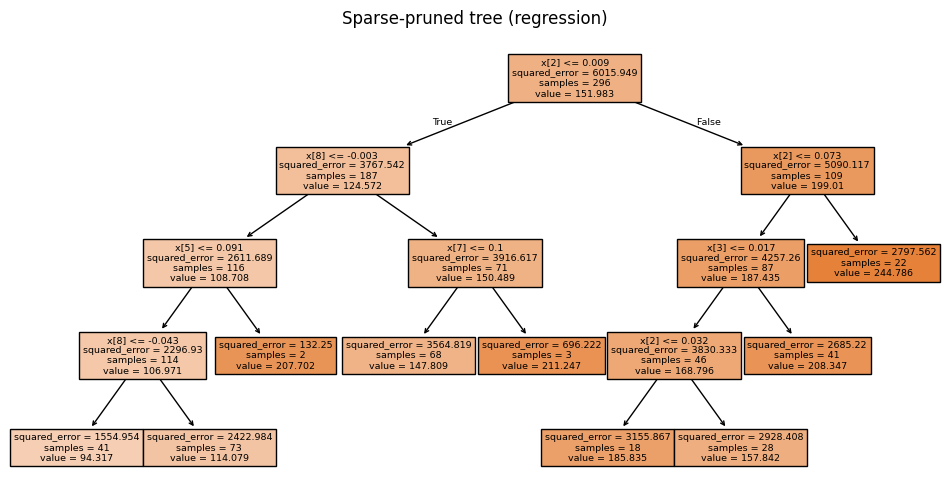

In [24]:
plt.figure(figsize=(12, 6))
tree.plot_tree(sp_tree.estimator_, max_depth=4, filled=True)
plt.title("Sparse-pruned tree (regression)")
plt.show()

In [25]:
dt = DecisionTreeRegressor(max_leaf_nodes=20, random_state=42)
dt.fit(X_train, y_train)

dt_mse = mean_squared_error(y_test, dt.predict(X_test))
dt_mse

4747.798197766451

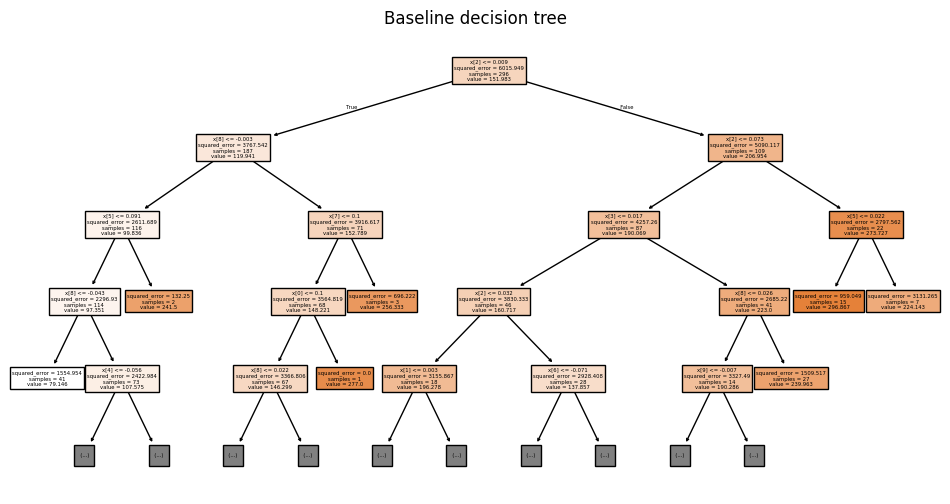

In [26]:
plt.figure(figsize=(12, 6))
tree.plot_tree(dt, max_depth=4, filled=True)
plt.title("Baseline decision tree")
plt.show()

In [27]:
sp_forest = SPTreeRegressor(
    estimator_=RandomForestRegressor(
        n_estimators=25, max_leaf_nodes=20, random_state=42
    ),
    sp_alpha=0.01,
    prune_set="oob",
)
sp_forest.fit(X_train, y_train)

sp_forest_mse = mean_squared_error(y_test, sp_forest.predict(X_test))
sp_forest_mse

2961.3399981443054

In [28]:
rf = RandomForestRegressor(n_estimators=25, max_leaf_nodes=20, random_state=42)
rf.fit(X_train, y_train)

rf_mse = mean_squared_error(y_test, rf.predict(X_test))
rf_mse

3041.451968658581